In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import stim
import numpy as np
import pymatching

from qecsim.surface_code_rotated.circuit import Rotated_Surface_Code
from qecsim.lattice_surgery.circuit import surgery_circuit

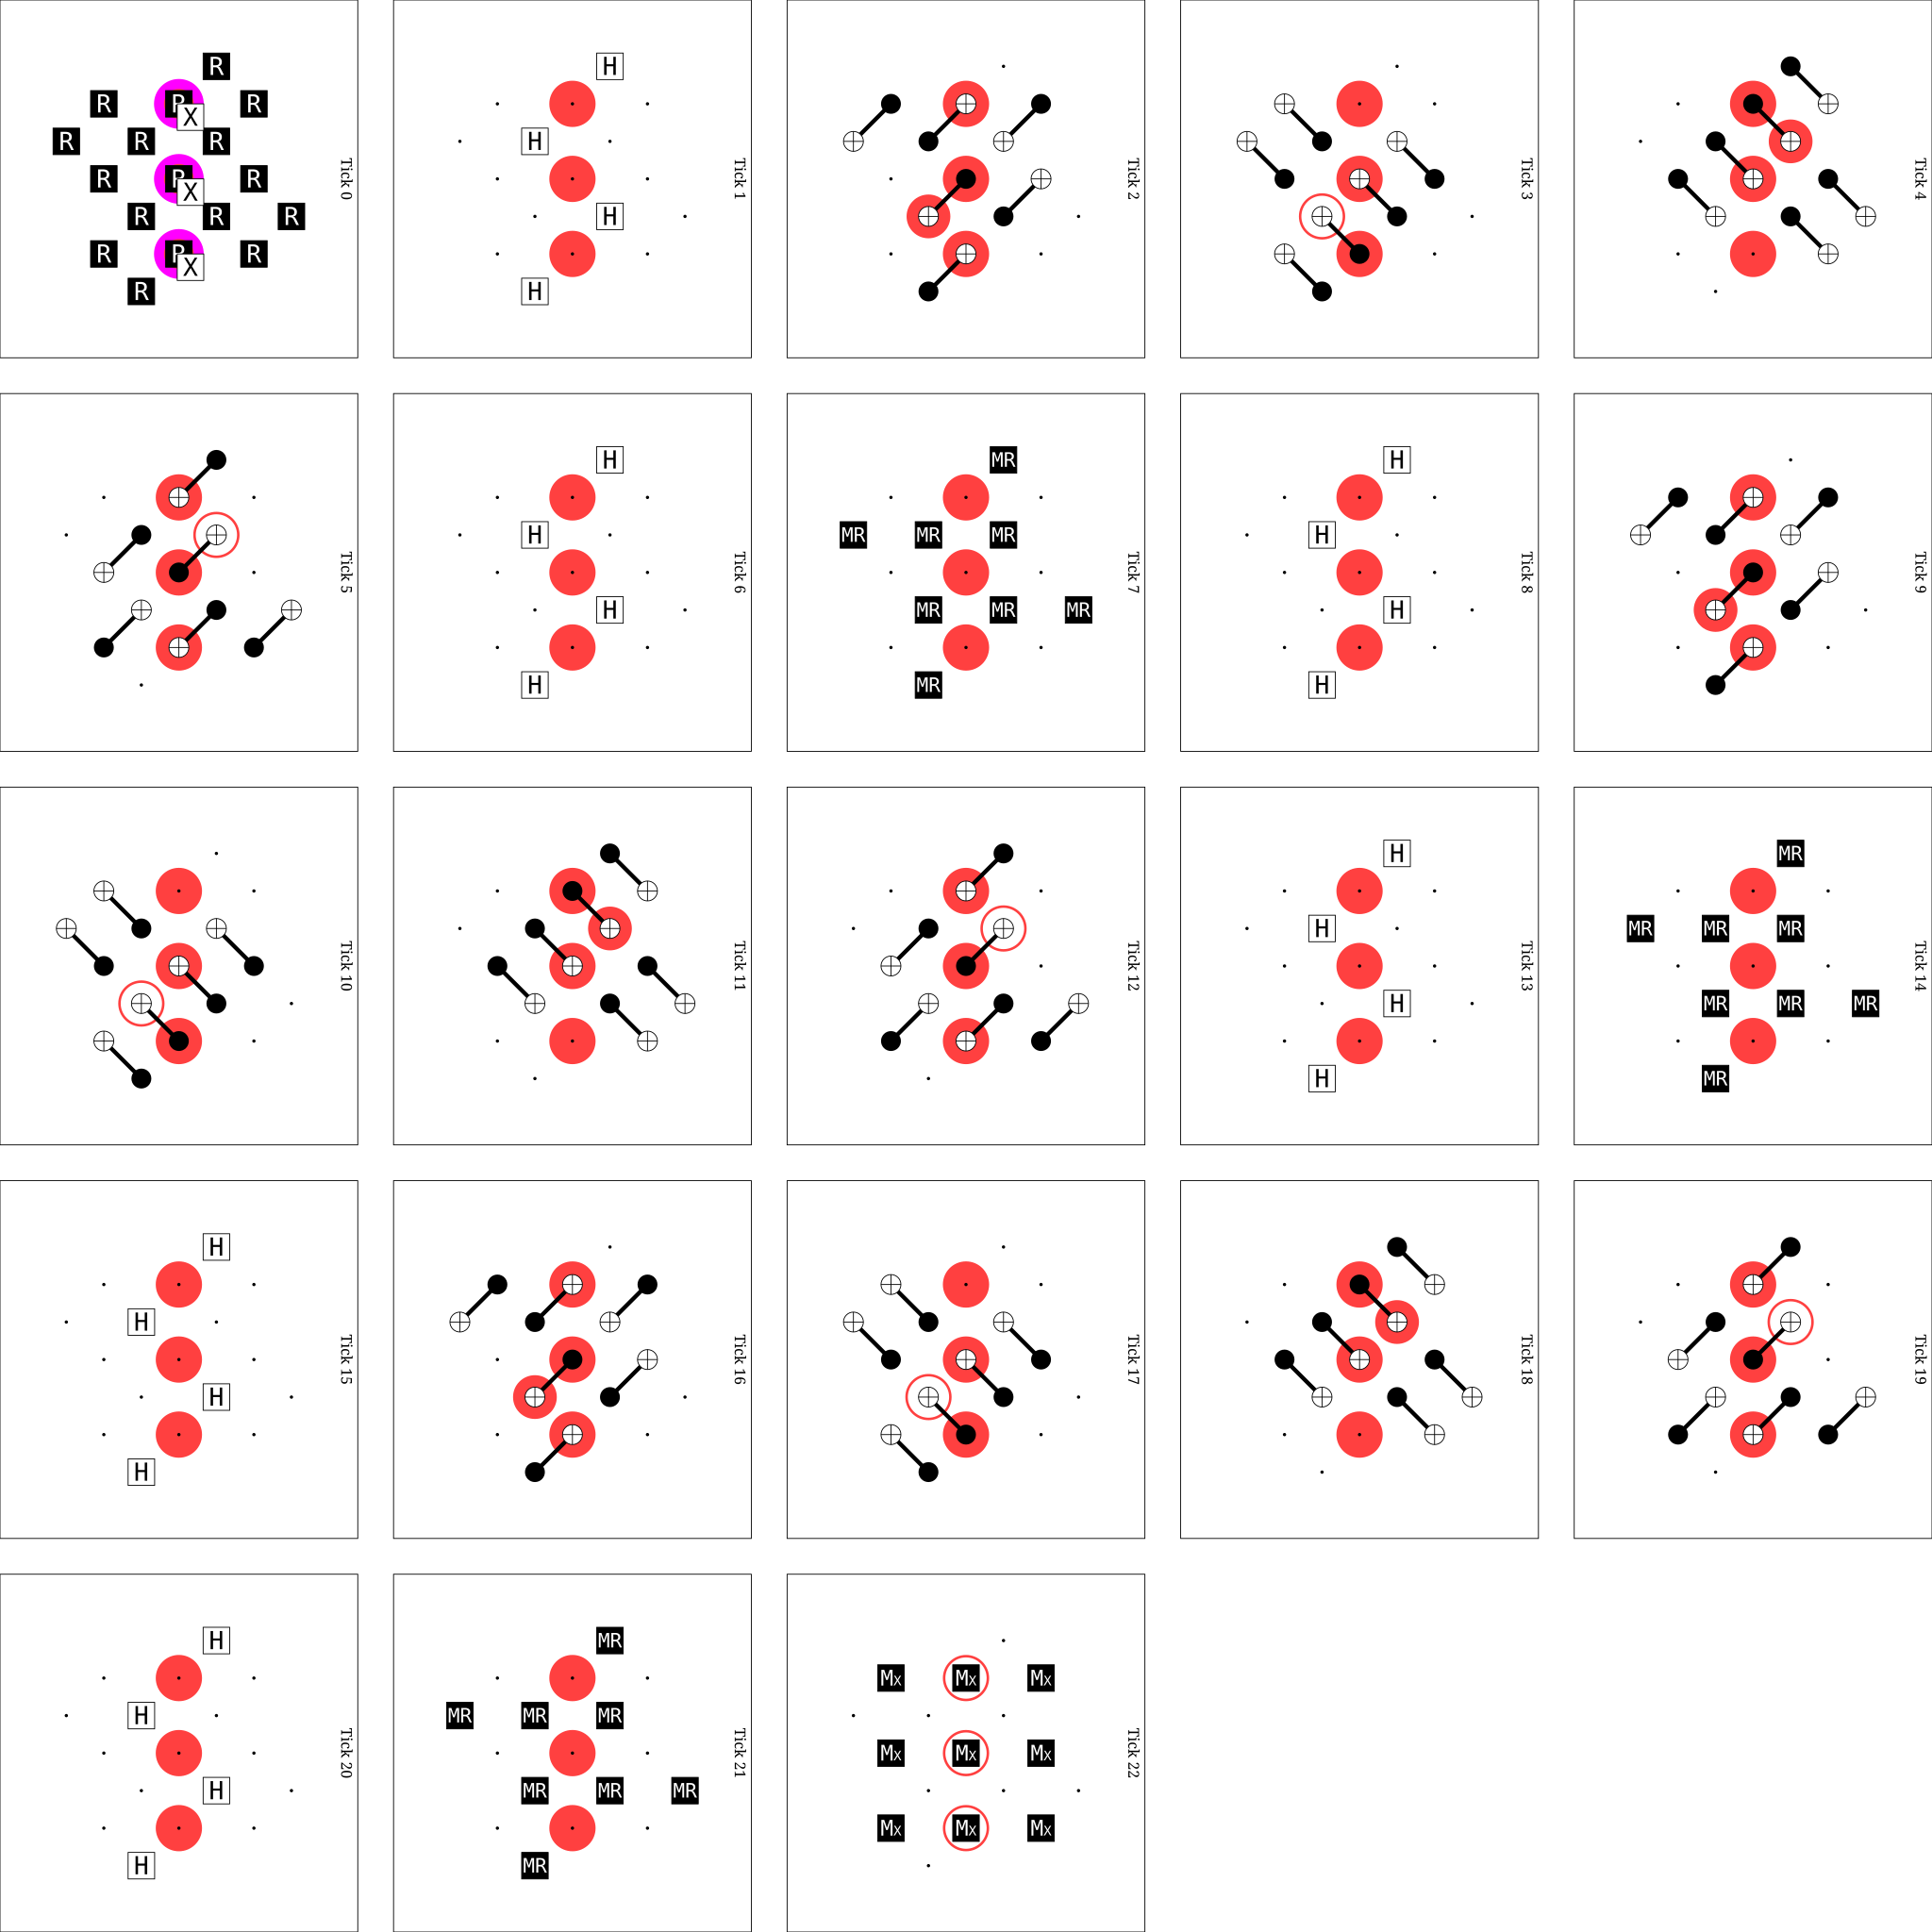

In [97]:
Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", init_state = "1").diagram("detslice-with-ops", filter_coords=["L0"])

In [20]:
c0 = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", init_state = "0")
c1 = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", init_state = "1")
cp = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", init_state = "+")
cm = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", init_state = "-")

In [43]:
def building_ptm(circuit_0: stim.Circuit, circuit_1: stim.Circuit, 
                 circuit_p: stim.Circuit, circuit_m: stim.Circuit, samples : int = 50) -> np.ndarray:

    """
    Building PTM by building each possible memory circuit and measurement combination
    -> + logical -> Measuring in x/z basis
    -> - logical -> Measuring in x/z basis
    -> 0 logical -> Measuring in x/z basis
    -> 1 logical -> Measuring in x/z basis
    """

    # Correct nosieless Measurements
    clean_meas0 = False
    clean_meas1 = True
    clean_measp = False
    clean_measm = True

    # Build a graphlike DEM and a matcher
    dem_0 = circuit_0.detector_error_model(decompose_errors=True)
    m_0 = pymatching.Matching.from_detector_error_model(dem_0)
    dem_1 = circuit_1.detector_error_model(decompose_errors=True)
    m_1 = pymatching.Matching.from_detector_error_model(dem_1)
    dem_p = circuit_p.detector_error_model(decompose_errors=True)
    m_p = pymatching.Matching.from_detector_error_model(dem_p)
    dem_m = circuit_m.detector_error_model(decompose_errors=True)
    m_m = pymatching.Matching.from_detector_error_model(dem_m)

    # Take m shots of detection events
    sampler_0 = circuit_0.compile_detector_sampler()
    dets_0, obs_0 = sampler_0.sample(samples, separate_observables=True)
    
    sampler_1 = circuit_1.compile_detector_sampler()
    dets_1, obs_1 = sampler_1.sample(samples, separate_observables=True)

    sampler_p = circuit_p.compile_detector_sampler()
    dets_p, obs_p = sampler_p.sample(samples, separate_observables=True)
    
    sampler_m = circuit_m.compile_detector_sampler()
    dets_m, obs_m = sampler_m.sample(samples, separate_observables=True)
    
    # Decode all sample round in one Batch decode
    pred_0 = m_0.decode_batch(dets_0)
    pred_1 = m_1.decode_batch(dets_1)
    pred_p = m_p.decode_batch(dets_p)
    pred_m = m_m.decode_batch(dets_m)

    # XOR flip with noiseless Measurement
    # -> Taking first entry for first logical observable
    final_meas0 = 1 - 2 * (pred_0[:,0].astype(np.int8) ^ np.int8(clean_meas0))
    final_meas1 = 1 - 2 * (pred_1[:,0].astype(np.int8) ^ np.int8(clean_meas1))
    final_measp = 1 - 2 * (pred_p[:,0].astype(np.int8) ^ np.int8(clean_measp))
    final_measm = 1 - 2 * (pred_m[:,0].astype(np.int8) ^ np.int8(clean_measm))

    # Take the Average of each of them
    mu_z_pz = np.average(final_meas0)
    mu_z_mz = np.average(final_meas1)
    mu_x_px = np.average(final_measp)
    mu_x_mx = np.average(final_measm)

    # Calc PTM entries
    r_zz = 1/2 * (mu_z_pz - mu_z_mz)
    r_xx = 1/2 * (mu_x_px + mu_x_mx)

    # Create PTM Matrix
    ptm = [[r_xx, 0, 0], [0, r_zz, 0], [0, 0, 0]]

    return(np.array(ptm))

In [95]:
circuit = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", init_state = "0", before_measurement_flip_prob = 0.1)
building_ptm(circuit_0 = circuit, circuit_1 = circuit, circuit_m = circuit, circuit_p = circuit, samples = 200)

array([[-0.005,  0.   ,  0.   ],
       [ 0.   ,  0.6  ,  0.   ],
       [ 0.   ,  0.   ,  0.   ]])